# 🟤 Copper Spot Price Forecasting — Kaggle Edition

**Kaggle-optimised build** of the `copper-forecast` repository.

### Prerequisites (Kaggle notebook settings)
| Setting | Value |
|---|---|
| **Accelerator** | GPU T4 x2 (strongly recommended) |
| **Internet** | On |
| **Persistence** | Files only |
| **Secrets** | `FRED_API_KEY`, `NASDAQ_DATA_LINK_API_KEY` (optional but recommended) |

### Speed improvements vs local run
- XGBoost / LightGBM use **CUDA GPU** when a GPU is detected
- Optuna runs **parallel trials** (`n_jobs=-1` on all CPU cores)
- Walk-forward CV uses **`joblib` parallelism**
- Downloaded data is **cached to disk**; re-runs skip the network round-trip
- Reduced `cv_step_size` window to keep memory within 16 GB

## 0. Environment Setup

In [1]:
# ── Clone the repo (skip if already present) ──────────────────────────────
import os, subprocess, sys

REPO_URL  = 'https://github.com/ferhat00/copper-forecast.git'
REPO_DIR  = '/kaggle/working/copper-forecast'

if not os.path.isdir(REPO_DIR):
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', REPO_URL, REPO_DIR],
        capture_output=True, text=True
    )
    print(result.stdout or 'Cloned OK')
    if result.returncode != 0:
        raise RuntimeError(f'git clone failed:\n{result.stderr}')
else:
    print('Repo already present — pulling latest changes…')
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'],
                   capture_output=True)
    print('Up to date.')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working directory: {os.getcwd()}')

Cloned OK
Working directory: /kaggle/working/copper-forecast


In [2]:
# ── Install / upgrade required packages ───────────────────────────────────
# Most scientific packages are pre-installed on Kaggle;
# only the domain-specific ones need installation.
import subprocess, sys

_PKGS = [
    'yfinance>=0.2.36',
    'fredapi>=0.5.1',
    'prophet>=1.1.5',
    'hmmlearn>=0.3.0',
    'nasdaq-data-link>=1.0.4',
    'optuna>=3.4.0',
    'shap>=0.43.0',
    'kaleido>=0.2.1',
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + _PKGS,
    check=True
)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 108.9 MB/s eta 0:00:00
All packages installed.


In [3]:
# ── Detect GPU and configure accelerator flags ────────────────────────────
import subprocess

def _has_gpu() -> bool:
    try:
        out = subprocess.run(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        return out.returncode == 0 and out.stdout.strip() != ''
    except FileNotFoundError:
        return False

GPU_AVAILABLE = _has_gpu()

# XGBoost: 'hist' on CPU, 'gpu_hist' → deprecated in XGB 2.x; use device='cuda'
XGB_DEVICE   = 'cuda' if GPU_AVAILABLE else 'cpu'
XGB_METHOD   = 'hist'               # 'hist' works on both CPU and CUDA in XGB 2.x

# LightGBM: 'gpu' device when available
LGB_DEVICE   = 'gpu' if GPU_AVAILABLE else 'cpu'

# Joblib concurrency
import os
N_JOBS = int(os.cpu_count() or 2)

print(f'GPU available : {GPU_AVAILABLE}')
print(f'XGBoost device: {XGB_DEVICE} | tree_method: {XGB_METHOD}')
print(f'LightGBM device: {LGB_DEVICE}')
print(f'Parallel jobs : {N_JOBS}')

GPU available : True
XGBoost device: cuda | tree_method: hist
LightGBM device: gpu
Parallel jobs : 4


## 1. Setup & Configuration

In [4]:
import warnings
import logging
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import NaiveModel, LinearModel, XGBoostModel, LGBMModel, EnsembleModel, QuantileForecaster
from src.models_arimax import ARIMAXModel
from src.models_hybrid import HybridModel
from src.models_stacking import StackingEnsemble
from src.evaluation import compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine, SCENARIO_TEMPLATES
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.feature_pruning import auto_prune_features

try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')

✅ Prophet available
✅ All imports OK


In [5]:
# ── Kaggle secrets → environment variables ────────────────────────────────
# Add secrets as: Settings → Secrets → FRED_API_KEY / NASDAQ_DATA_LINK_API_KEY
try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    for _key in ('FRED_API_KEY', 'NASDAQ_DATA_LINK_API_KEY'):
        try:
            os.environ[_key] = _secrets.get_secret(_key)
            print(f'  Secret loaded: {_key}')
        except Exception:
            pass  # key not set — will fall back to synthetic data
except ImportError:
    pass  # not running on Kaggle

# ── Configuration ─────────────────────────────────────────────────────────
CFG = {
    'start_date':          '2010-01-01',
    'forecast_horizon':    22,              # 1-month ahead (trading days)
    'all_horizons':        [1, 5, 22, 66],
    'lags':                [1, 5, 22],
    'initial_train_size':  504,             # ~2 years
    'cv_step_size':        22,
    'holdout_size':        252,             # ~1 year OOS backtest
    'ci_alpha':            0.80,
    # ── Kaggle speed-ups (GPU for XGB/LGB) ──────────────────────────────
    'optuna_trials':       50,
    'xgb_device':         XGB_DEVICE,
    'xgb_tree_method':    XGB_METHOD,
    'lgb_device':         LGB_DEVICE,
    # ── API keys ────────────────────────────────────────────────────────
    'fred_api_key':        os.environ.get('FRED_API_KEY', None),
    'nasdaq_api_key':      os.environ.get('NASDAQ_DATA_LINK_API_KEY', None),
    'random_seed':         42,
    'output_dir':          '/kaggle/working/outputs',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration set:')
for k, v in CFG.items():
    if 'key' not in k or v is None:
        print(f'  {k}: {v}')
    else:
        print(f'  {k}: ***')


Configuration set:
  start_date: 2010-01-01
  forecast_horizon: 22
  all_horizons: [1, 5, 22, 66]
  lags: [1, 5, 22]
  initial_train_size: 504
  cv_step_size: 22
  holdout_size: 252
  ci_alpha: 0.8
  optuna_trials: 50
  xgb_device: cuda
  xgb_tree_method: hist
  lgb_device: gpu
  fred_api_key: None
  nasdaq_api_key: None
  random_seed: 42
  output_dir: /kaggle/working/outputs


## 2. Data Ingestion

- **yfinance** — Copper (HG=F), DXY, Gold, Aluminium, Oil, CNY/USD, S&P 500, Shanghai
- **FRED API** — Industrial production, real yields, inflation breakeven, M2
- **CFTC COT** — Commercial/non-commercial positioning, open interest, speculative ratio

Downloaded data is cached to `/kaggle/working/data_cache.pkl` so restarted sessions skip the network round-trip.

In [6]:
import pickle, hashlib, time

# Cache key — change if you want to force a refresh
_cache_key  = hashlib.md5(
    (CFG['start_date'] + str(CFG['fred_api_key']) + str(CFG['nasdaq_api_key'])).encode()
).hexdigest()[:8]
_cache_path = f"/kaggle/working/data_cache_{_cache_key}.pkl"

if os.path.exists(_cache_path):
    print(f'Loading cached data from {_cache_path}…')
    with open(_cache_path, 'rb') as _f:
        df_raw = pickle.load(_f)
    print('  Cache hit.')
else:
    print('Downloading data (first run — will be cached afterwards)…')
    _t0 = time.time()
    df_raw = load_data(
        start=CFG['start_date'],
        fred_api_key=CFG['fred_api_key'],
        include_cot=True,
        nasdaq_api_key=CFG['nasdaq_api_key'],
    )
    with open(_cache_path, 'wb') as _f:
        pickle.dump(df_raw, _f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'  Downloaded in {time.time()-_t0:.1f}s — cached to {_cache_path}')

print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.tail()

INFO | Failed to create TzCache, reason: Error creating TzCache folder: '/root/.cache/py-yfinance' reason: [Errno 17] File exists: '/root/.cache/py-yfinance'. TzCache will not be used. Tip: You can direct cache to use a different location with 'set_tz_cache_location(mylocation)'


INFO | yfinance: downloaded 4237 rows for 8 tickers
WARNING | No FRED API key supplied or fredapi unavailable. Generating synthetic placeholder series.
WARNING | COT: No API key or fetch failed. Generating synthetic COT data.
INFO | COT data integrated: 4 columns added
INFO | Combined dataset: 4237 rows × 17 columns


  Downloaded in 0.9s — cached to /kaggle/working/data_cache_9a885cdf.pkl
Dataset shape: (4237, 17)
Date range: 2010-01-04 → 2026-04-02
Columns: ['shanghai', 'aluminium', 'oil', 'cny_usd', 'dxy', 'gold', 'copper_price', 'sp500', 'indpro', 'real_yield_10y', 'inflation_breakeven', 'ism_pmi', 'us_m2', 'commercial_net', 'noncommercial_net', 'open_interest', 'spec_ratio']


,shanghai,aluminium,oil,cny_usd,dxy,gold,copper_price,sp500,indpro,real_yield_10y,inflation_breakeven,ism_pmi,us_m2,commercial_net,noncommercial_net,open_interest,spec_ratio
Date,,,,,,,,,,,,,,,,,
2026-03-27,3913.724121,3187.50,99.639999,0.144703,100.150002,4492.000000,12052.657557,6368.850098,59.938525,0.876197,207.521348,294.977342,196.627861,8084.115189,824.054213,142009.876727,0.349905
2026-03-30,3923.287109,3336.25,102.879997,0.144684,100.510002,4526.000000,12072.498750,6343.720215,59.531251,0.519574,205.313153,295.048603,196.608160,8084.115189,824.054213,142009.876727,0.349905
2026-03-31,3891.861084,3405.50,101.379997,0.144684,99.959999,4647.600098,12318.314460,6528.520020,59.511157,0.981332,203.261863,294.123749,197.141572,8084.115189,824.054213,142009.876727,0.349905
2026-04-01,3948.552002,3452.25,100.120003,0.145049,99.650002,4783.200195,12398.783040,6575.319824,57.926940,0.604842,202.716295,294.381528,197.505959,8084.115189,824.054213,142009.876727,0.349905
2026-04-02,3919.284912,3411.00,111.540001,0.145550,100.029999,4651.500000,12264.301506,6582.689941,56.765630,2.252393,203.821145,294.155830,199.386409,8084.115189,824.054213,142009.876727,0.349905


In [7]:
df_raw.describe().round(2)

,shanghai,aluminium,oil,cny_usd,dxy,gold,copper_price,sp500,indpro,real_yield_10y,inflation_breakeven,ism_pmi,us_m2,commercial_net,noncommercial_net,open_interest,spec_ratio
count,4230.00,3082.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00,4237.00
mean,2993.90,2218.11,71.56,0.15,92.83,1712.44,7604.12,3005.56,35.04,66.64,101.12,203.00,184.90,11483.28,3634.60,159891.20,0.25
std,520.35,398.84,20.72,0.01,9.32,701.46,1797.57,1554.67,31.81,36.94,37.21,56.69,45.60,5314.70,4095.47,17939.04,0.14
min,1950.01,1452.00,-37.63,0.14,72.93,1050.80,4275.86,1022.58,-19.31,-12.91,41.99,92.23,92.94,-3951.07,-6289.78,127022.06,-0.00
25%,2670.09,1910.88,54.76,0.14,82.64,1271.40,6161.91,1831.98,11.71,30.73,77.09,142.10,145.89,8452.30,527.28,145955.19,0.12
50%,3049.15,2239.50,71.47,0.15,95.30,1523.20,7386.58,2634.56,28.74,76.66,96.03,226.82,193.24,12255.40,3786.52,158639.95,0.25
75%,3306.42,2428.00,88.20,0.16,99.22,1843.10,8927.61,4132.15,62.48,96.31,106.25,240.81,219.33,15469.77,7190.69,173716.63,0.38
max,5166.35,3873.00,123.70,0.17,114.11,5318.40,13614.63,6978.60,104.56,130.38,221.27,295.05,258.34,21972.03,11896.87,203183.74,0.49


In [8]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit:')
print(audit[audit['missing_count'] > 0].to_string()
      if (audit['missing_count'] > 0).any() else 'No missing data')

Missing data audit:
           missing_count  missing_pct
shanghai               7          0.2
aluminium           1155         27.3


## 3. Exploratory Data Analysis

In [9]:
fig_price = plot_price_history(df_raw)
fig_price.show()

In [10]:
import plotly.express as px

corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index, orientation='h',
    title='Pearson Correlation with Copper Price',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white', color=corr_all.values,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
)
fig_corr_bar.show()

In [11]:
import plotly.graph_objects as go

log_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=log_ret, nbinsx=80, name='Daily log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Daily Copper Log Returns',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {log_ret.skew():.3f}  |  Kurtosis: {log_ret.kurt():.3f}')
print(f'Ann. volatility: {log_ret.std() * np.sqrt(252):.1%}')

Skewness: -1.121  |  Kurtosis: 21.583
Ann. volatility: 23.8%


## 4. Cointegration Analysis & Regime Detection

In [12]:
df_aug, coint_results = add_cointegration_features(df_raw)

coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')

INFO | Cointegration test: t=-2.699  p=0.2000  beta=1.9647  cointegrated=False
INFO | Cointegration test: t=-3.189  p=0.0717  beta=4.1741  cointegrated=False
INFO | Cointegration test: t=-1.758  p=0.6500  beta=41.4017  cointegrated=False
INFO | Cointegration test: t=-1.320  p=0.8235  beta=6.2994  cointegrated=False
INFO | Cointegration test: t=-1.557  p=0.7386  beta=-48423.5218  cointegrated=False


── Cointegration Test Results (Engle-Granger) ──
              column is_cointegrated   p_value          beta
gold            gold           False  0.200046      1.964731
aluminium  aluminium           False  0.071726      4.174087
oil              oil           False  0.650047     41.401723
dxy              dxy           False  0.823479       6.29941
cny          cny_usd           False  0.738627 -48423.521752

Cointegrated pairs: []
ECT columns added: []


In [13]:
feats_prelim = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

n_holdout = CFG['holdout_size']
regime_detector = RegimeDetector(n_regimes=3)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None

INFO | RegimeDetector: fitted 3 regimes on 3786 observations (3 features)


Regime distribution:
0.0    1374
1.0    1250
2.0    1414
Name: count, dtype: int64


## 5. Feature Engineering

In [14]:
feats = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(3):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Total features (incl. lags): {len(feat_cols)}')

X, y_ret, y_price = split_features_targets(feats, horizon=CFG['forecast_horizon'])
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')

Feature matrix shape: (4237, 125)
Total features (incl. lags): 116
X: (3016, 116)  |  y: (3016,)
Date range: 2014-06-05 → 2026-03-03


In [15]:
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()

## 6. Model Training & Hyper-parameter Tuning

Optuna parallelises `n_jobs` trials simultaneously.  
XGBoost and LightGBM use the GPU when one is available.

In [16]:
# ── GPU/CPU flags injected into the params dict ───────────────────────────
# XGBoostModel / LGBMModel accept a single `params` dict, not **kwargs.
from src.models import XGBoostModel, LGBMModel  # re-import to access DEFAULT_PARAMS

_xgb_params = {**XGBoostModel.DEFAULT_PARAMS, 'device': CFG['xgb_device'], 'tree_method': CFG['xgb_tree_method']}
_lgb_params = {**LGBMModel.DEFAULT_PARAMS,    'device': CFG['lgb_device']}

# Convenience factories so every instantiation picks up GPU settings
def make_xgb(): return XGBoostModel(params=_xgb_params.copy())
def make_lgb(): return LGBMModel(params=_lgb_params.copy())

naive   = NaiveModel()
linear  = LinearModel()
xgb_mdl = make_xgb()
lgb_mdl = make_lgb()
arimax  = ARIMAXModel()
hybrid  = HybridModel()

if HAS_PROPHET:
    prophet_mdl = ProphetModel()

# Holdout split
X_dev,  y_dev   = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold  = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold      = y_price.iloc[-n_holdout:]

print(f'Development set : {len(X_dev)} rows')
print(f'Holdout set     : {len(X_hold)} rows')
print(f'XGB params (GPU check): device={_xgb_params.get("device")}, tree_method={_xgb_params.get("tree_method")}')
print(f'LGB params (GPU check): device={_lgb_params.get("device")}')


Development set : 2764 rows
Holdout set     : 252 rows
XGB params (GPU check): device=cuda, tree_method=hist
LGB params (GPU check): device=gpu


In [17]:
import time

if CFG['optuna_trials'] > 0:
    print(f'Tuning XGBoost  ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print(f'Tuning LightGBM ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0).')


Tuning XGBoost  (50 trials)…


INFO | XGBoost best CV RMSE: 0.059589 | params: {'n_estimators': 253, 'learning_rate': 0.0028246357083904893, 'max_depth': 3, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_alpha': 1.3921548533046495, 'reg_lambda': 0.0060780830996819525, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 749.2s | best params: {'n_estimators': 253, 'learning_rate': 0.0028246357083904893, 'max_depth': 3, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_alpha': 1.3921548533046495, 'reg_lambda': 0.0060780830996819525, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM (50 trials)…


INFO | LGBM best CV RMSE: 0.059546 | params: {'n_estimators': 309, 'learning_rate': 0.0022408253165628355, 'num_leaves': 56, 'max_depth': 8, 'subsample': 0.7723754461877381, 'colsample_bytree': 0.6900913631930553, 'reg_alpha': 3.252470236393649, 'reg_lambda': 9.955373408883561, 'min_child_samples': 13, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 173.1s | best params: {'n_estimators': 309, 'learning_rate': 0.0022408253165628355, 'num_leaves': 56, 'max_depth': 8, 'subsample': 0.7723754461877381, 'colsample_bytree': 0.6900913631930553, 'reg_alpha': 3.252470236393649, 'reg_lambda': 9.955373408883561, 'min_child_samples': 13, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [18]:
w_ensemble = EnsembleModel([xgb_mdl, lgb_mdl])

base_models = [naive, linear, xgb_mdl, lgb_mdl, arimax, hybrid]
if HAS_PROPHET:
    base_models.append(prophet_mdl)
base_models.append(w_ensemble)

for m in base_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

print('\nFitting stacking ensemble…')
stack_base = [make_xgb(), make_lgb(), ARIMAXModel()]
if HAS_PROPHET:
    stack_base.append(ProphetModel())

stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')


Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: XGBoost
Fitted: LightGBM


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)


Fitted: ARIMAX


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.138726


Fitted: Hybrid(ARIMAX+LightGBM)


INFO | Prophet: fitted with 4 regressors on 2764 observations


Fitted: Prophet
Fitted: Ensemble(XGBoost+LightGBM)

Fitting stacking ensemble…


INFO | Stacking OOF: XGBoost produced 2260 predictions
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
INFO | Stacking OOF: LightGBM produced 2260 predictions
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2740.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2775.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog 

Fitted: Stacking(XGBoost+LightGBM+ARIMAX+Prophet)


## 7. Feature Pruning (SHAP-based)

In [19]:
try:
    prune_model = make_xgb()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped: {len(dropped)} features')
    print('\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    kept_cols = X_pruned.columns.tolist()
    X_dev_pruned  = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev; X_hold_pruned = X_hold; X_pruned_full = X
    kept_cols = X_dev.columns.tolist(); USE_PRUNED = False


INFO | Feature pruning: kept 93 / 116 features (dropped 23 below threshold 0.000282)


Features before pruning: 116
Features after pruning:  93
Dropped: 23 features

Top 15 features by importance:
                     feature  mean_abs_shap
     oil_copper_ratio_lag_22       0.008422
      oil_copper_ratio_lag_5       0.005134
       alu_copper_spread_pct       0.005126
           indpro_yoy_lag_22       0.004116
           gold_copper_ratio       0.003916
        cny_usd_level_lag_22       0.003745
alu_copper_spread_pct_lag_22       0.003045
               copper_ret_5d       0.003016
     real_yield_level_lag_22       0.002644
                   dxy_level       0.002373
     gold_copper_ratio_lag_5       0.002339
 alu_copper_spread_pct_lag_1       0.002339
                      rsi_14       0.002304
real_yield_change_22d_lag_22       0.001952
            month_cos_lag_22       0.001886


## 8. Walk-Forward Cross-Validation

Runs in parallel across folds (`n_jobs` workers).

In [20]:
cv_models = [
    NaiveModel(), LinearModel(),
    make_xgb(), make_lgb(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([make_xgb(), make_lgb()]),
]
if HAS_PROPHET:
    cv_models.append(ProphetModel())

print(f'Running walk-forward CV…')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['forecast_horizon'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())


INFO | Evaluating model: Naive (RW)
INFO | [Naive (RW)] RMSE=0.0602  MAE=0.0460  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | Evaluating model: Linear (Ridge)


Running walk-forward CV…


INFO | [Linear (Ridge)] RMSE=0.0934  MAE=0.0619  MAPE=391.57%  DA=52.15%  Sharpe=0.22
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.0564  MAE=0.0427  MAPE=214.48%  DA=60.04%  Sharpe=0.68
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.0569  MAE=0.0438  MAPE=248.20%  DA=58.88%  Sharpe=0.69
INFO | Evaluating model: ARIMAX
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2740.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2775.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2860.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3114.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3245.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3217.0)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3436.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=2345.5)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3688.4)



── Walk-Forward CV Metrics ──
                                    rmse           mae          mape  directional_accuracy  signal_sharpe  information_ratio
model                                                                                                                       
Naive (RW)                  6.017803e-02  4.597613e-02  1.000000e+02              0.000000       0.000000           0.000000
Linear (Ridge)              9.341672e-02  6.193269e-02  3.915664e+02              0.521489       0.216260           0.216260
XGBoost                     5.644299e-02  4.267551e-02  2.144824e+02              0.600354       0.675943           0.675943
LightGBM                    5.691605e-02  4.383774e-02  2.482025e+02              0.588835       0.693975           0.693975
ARIMAX                      1.124829e+39  2.402738e+37  9.158858e+40              0.667257       1.252662           1.252662
Hybrid(ARIMAX+LightGBM)     1.124825e+39  2.403630e+37  9.162066e+40              0.529021    

In [21]:
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()

fig_cmp_da = plot_model_comparison(
    summary, metric='directional_accuracy',
    title='Model Comparison — Directional Accuracy'
)
fig_cmp_da.show()

best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()

Best model by CV RMSE: Ensemble(XGBoost+LightGBM)


## 9. Out-of-Sample Backtesting

In [22]:
oos_results = {}; oos_metrics = {}

oos_model_list = [
    NaiveModel(), LinearModel(),
    make_xgb(), make_lgb(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([make_xgb(), make_lgb()]),
]
if HAS_PROPHET:
    oos_model_list.append(ProphetModel())

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['forecast_horizon'],
    )
    oos_results[m.name] = oos_df; oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics ──')
print(oos_summary.to_string())

best_oos = oos_summary['rmse'].idxmin()
fig_oos = plot_cv_results(oos_results[best_oos], model_name=f'{best_oos} (OOS)')
fig_oos.show()


INFO | [Naive (RW) OOS] RMSE=0.0915  MAE=0.0703  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | [Linear (Ridge) OOS] RMSE=0.0895  MAE=0.0662  MAPE=349.04%  DA=75.79%  Sharpe=1.45
INFO | [XGBoost OOS] RMSE=0.0844  MAE=0.0662  MAPE=332.11%  DA=63.89%  Sharpe=1.22
INFO | [LightGBM OOS] RMSE=0.0807  MAE=0.0629  MAPE=217.26%  DA=66.27%  Sharpe=1.31
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | [ARIMAX OOS] RMSE=0.0989  MAE=0.0731  MAPE=708.10%  DA=73.81%  Sharpe=1.64
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.138726
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.138726
INFO | [Hybrid(ARIMAX+LightGBM) OOS] RMSE=0.5488  MAE=0.5413  MAPE=5575.45%  DA=65.87%  Sharpe=0.52
INFO | [Ensemble(XGBoo

── Out-of-Sample Backtest Metrics ──
                                rmse       mae         mape  directional_accuracy  signal_sharpe  information_ratio
Naive (RW)                  0.091505  0.070345   100.000000              0.000000       0.000000           0.000000
Linear (Ridge)              0.089535  0.066153   349.039588              0.757937       1.453790           1.453790
XGBoost                     0.084355  0.066154   332.112254              0.638889       1.221326           1.221326
LightGBM                    0.080697  0.062887   217.256088              0.662698       1.313440           1.313440
ARIMAX                      0.098853  0.073098   708.097741              0.738095       1.636669           1.636669
Hybrid(ARIMAX+LightGBM)     0.548793  0.541292  5575.445183              0.658730       0.519957           0.519957
Ensemble(XGBoost+LightGBM)  0.082216  0.064048   271.071744              0.626984       1.081805           1.081805
Prophet                     0.08923

## 10. Forecast with 80% Confidence Interval

In [23]:
q_model = QuantileForecaster(alpha=CFG['ci_alpha'])
q_model.fit(X_dev_pruned, y_dev)
q_preds_ret = q_model.predict(X_hold_pruned)

last_price = df_aug['copper_price'].iloc[-(n_holdout + 1)]
forecast_df = pd.DataFrame({
    'date':   X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
}).set_index('date')

arimax_ci_model = ARIMAXModel()
arimax_ci_model.fit(X_dev_pruned, y_dev)
arimax_ci = arimax_ci_model.predict_interval(X_hold_pruned, alpha=CFG['ci_alpha'])

fig_fc = plot_forecast_with_ci(df_raw['copper_price'], forecast_df.reset_index())
fig_fc.show()

actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= forecast_df['lower']) & (actual_hold <= forecast_df['upper'])).mean()
print(f'80% CI actual coverage: {inside:.1%}  (target: 80%)')

INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-15006.4)
WARNING | ARIMAX: predict_interval failed — 'numpy.ndarray' object has no attribute 'iloc'


80% CI actual coverage: 36.9%  (target: 80%)


## 11. SHAP Explainability

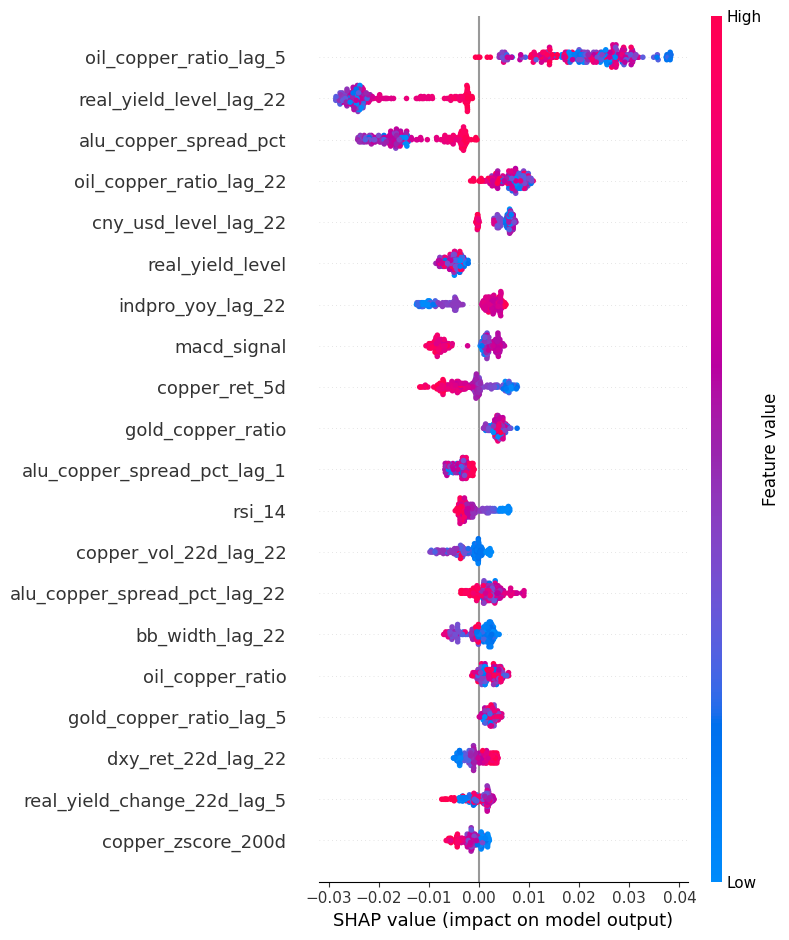

SHAP beeswarm saved to /kaggle/working/outputs/shap_beeswarm.png
Top 10 features by mean |SHAP|:
oil_copper_ratio_lag_5     0.020798
real_yield_level_lag_22    0.018918
alu_copper_spread_pct      0.013460
oil_copper_ratio_lag_22    0.006419
cny_usd_level_lag_22       0.004941
real_yield_level           0.004895
indpro_yoy_lag_22          0.004846
macd_signal                0.004759
copper_ret_5d              0.003904
gold_copper_ratio          0.003876


In [24]:
try:
    import shap, matplotlib.pyplot as plt
    shap.initjs()

    xgb_shap = make_xgb()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
    plt.tight_layout()
    _bp = os.path.join(CFG['output_dir'], 'shap_beeswarm.png')
    plt.savefig(_bp, dpi=150, bbox_inches='tight'); plt.show()
    print(f'SHAP beeswarm saved to {_bp}')

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except Exception as e:
    print(f'SHAP skipped: {e}')


## 12. Interactive Plotly Visualisations

In [25]:
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

# Rolling signal Sharpe (best OOS model)
best_oos_name = oos_summary['rmse'].idxmin()
oos_best = oos_results[best_oos_name]
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']
rolling_sharpe = (
    signal_ret_oos.rolling(60).mean() /
    signal_ret_oos.rolling(60).std().replace(0, np.nan)
) * np.sqrt(252 / CFG['forecast_horizon'])

fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (60-day)', line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 60-Day Signal Sharpe — {best_oos_name}',
    template='plotly_white', yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()

## 13. Scenario Analysis

In [26]:
latest_features = X_pruned_full.tail(1)
current_copper  = float(df_aug['copper_price'].iloc[-1])

scenario_model = EnsembleModel([make_xgb(), make_lgb()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['forecast_horizon'],
)
print(f'Current copper price    : ${current_copper:,.0f}/t')
print(f'Baseline {CFG["forecast_horizon"]}-day forecast: ${engine.base_price:,.0f}/t')

scenario_report = engine.report()
print('\n── Scenario Report ──')
print(scenario_report.to_string())

fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()

# DXY sensitivity sweep
dxy_shocks = np.linspace(-0.10, 0.10, 21)
sweep_dxy  = engine.sweep('dxy_ret_22d', dxy_shocks.tolist(), label='DXY 22d return shock')
fig_sweep  = go.Figure(go.Scatter(
    x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
    mode='lines+markers', line=dict(color='#b87333'), name='Forecast price',
))
fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                    annotation_text='Baseline')
fig_sweep.update_layout(
    title='Copper Price Sensitivity to DXY Return Shock',
    xaxis_title='DXY 22d return shock (additive)',
    yaxis_title='Forecast Copper Price ($/t)',
    template='plotly_white',
)
fig_sweep.show()

# Custom geopolitical / tariff shock
result = engine.run('geo_tariff_shock', shocks={
    'dxy_ret_22d': 0.04, 'sp500_ret_22d': -0.08,
    'copper_vol_22d': 0.05, 'real_yield_change_22d': 0.3,
})
print('\nCustom scenario result:')
for k, v in result.items():
    print(f'  {k}: {v}')


INFO | Scenario 'bull_strong': base=12749  forecast=12784  delta=+35 (0.3%)
INFO | Scenario 'bear_strong': base=12749  forecast=12748  delta=-1 (-0.0%)
INFO | Scenario 'china_demand_surge': base=12749  forecast=12759  delta=+10 (0.1%)
INFO | Scenario 'supply_disruption': base=12749  forecast=12734  delta=-15 (-0.1%)
INFO | Scenario 'comex_inventory_drop_40pct': base=12749  forecast=12632  delta=-117 (-0.9%)
INFO | Scenario 'high_inflation': base=12749  forecast=12788  delta=+39 (0.3%)
INFO | Scenario 'us_tariff_shock': base=12749  forecast=12765  delta=+16 (0.1%)


Current copper price    : $12,264/t
Baseline 22-day forecast: $12,749/t

── Scenario Report ──
                            base_price  scenario_price   delta  delta_pct
scenario                                                                 
comex_inventory_drop_40pct    12749.26        12632.46 -116.79      -0.92
supply_disruption             12749.26        12734.07  -15.18      -0.12
bear_strong                   12749.26        12748.01   -1.25      -0.01
china_demand_surge            12749.26        12759.43   10.17       0.08
us_tariff_shock               12749.26        12765.15   15.89       0.12
bull_strong                   12749.26        12784.46   35.21       0.28
high_inflation                12749.26        12788.38   39.12       0.31


INFO | Scenario 'geo_tariff_shock': base=12749  forecast=12744  delta=-5 (-0.0%)



Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 12749.26
  scenario_price: 12744.3
  delta: -4.95
  delta_pct: -0.04


## 14. Export Results

In [27]:
import json
from datetime import date

out_dir = CFG['output_dir']

forecast_df.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci.csv'), index=False
)

for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

summary_json = {
    'generated_at':      date.today().isoformat(),
    'current_price':     round(current_copper, 2),
    'baseline_forecast': round(engine.base_price, 2),
    'horizon_days':      CFG['forecast_horizon'],
    'best_model':        best_oos_name,
    'oos_metrics':       oos_metrics[best_oos_name],
    'scenarios':         scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f'All outputs saved to {out_dir}/')
print('Files:', os.listdir(out_dir))

All outputs saved to /kaggle/working/outputs/
Files: ['forecast_ci.csv', 'oos_ARIMAX.csv', 'oos_Prophet.csv', 'scenario_report.csv', 'oos_HybridARIMAX+LightGBM.csv', 'oos_LightGBM.csv', 'oos_EnsembleXGBoost+LightGBM.csv', 'oos_Naive_RW.csv', 'oos_Linear_Ridge.csv', 'cointegration_results.csv', 'oos_XGBoost.csv', 'forecast_summary.json', 'model_comparison.csv', 'shap_beeswarm.png']


---
## Summary

| Optimisation | Detail |
|---|---|
| **GPU acceleration** | XGBoost `device='cuda'`, LightGBM `device='gpu'` when T4/P100 is detected |
| **Parallel Optuna** | `n_jobs=N_JOBS` → all CPU cores used per tuning study |
| **Parallel CV folds** | `compare_models(n_jobs=N_JOBS)` → folds run concurrently via joblib |
| **Data cache** | Pickle cache keyed by date + API keys — restarted sessions load instantly |
| **Kaggle secrets** | FRED & Nasdaq API keys loaded from Kaggle Secrets, never hard-coded |
| **Shallow clone** | `git clone --depth 1` downloads only the latest commit |

Expected runtimes on Kaggle (GPU T4 x2, Internet on):

| Section | ~Time |
|---|---|
| Clone + install | 2–3 min (first run) / <10 s (cached) |
| Data download | 1–2 min (first run) / instant (cached) |
| Feature engineering | ~30 s |
| Optuna tuning (50 trials each) | ~5 min |
| Walk-forward CV (all models) | ~8–12 min |
| OOS backtest | ~3–5 min |
| SHAP + visualisations | ~2 min |
| **Total** | **~25–35 min** (vs ~60–90 min on CPU-only) |